In [ ]:
# MNIST Digit Classification using a Convolutional Neural Network (CNN)
# Implemented with PyTorch Lightning for structured training and evaluation

In [ ]:
# ==== Imports and setup =====

%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from torchmetrics import Accuracy
from pytorch_lightning.loggers import CSVLogger
import glob
from torchvision.datasets import MNIST
from torchvision import transforms
import model

pl.seed_everything(25)

In [17]:
# ==== Dataset and dataloaders ====

train_dataset = MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())
train_dataloader = DataLoader(train_dataset, batch_size = 100, shuffle = True) 
test_dataloader = DataLoader(test_dataset, batch_size = 100, shuffle = False)

In [ ]:
# ==== Training ====

CNN = model.MNISTCNN()
lightning_model = model.MNISTClassifier(model=CNN, learning_rate=1e-3)
logger = CSVLogger("logs", name="mnist")
trainer = pl.Trainer(max_epochs=5, accelerator="auto", devices="auto", logger=logger)
trainer.fit(model=lightning_model, train_dataloaders=train_dataloader, val_dataloaders=test_dataloader)

In [26]:
# ==== Model accuracy and loss metrics ====

metrics_path = glob.glob("logs/mnist/**/metrics.csv", recursive=True)[0]
metrics = pd.read_csv(metrics_path)
final_val_acc = metrics["val_acc"].dropna().iloc[-1]
final_val_loss = metrics["val_loss"].dropna().iloc[-1]
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Validation Accuracy: 0.8095
Final Validation Loss: 1.0463


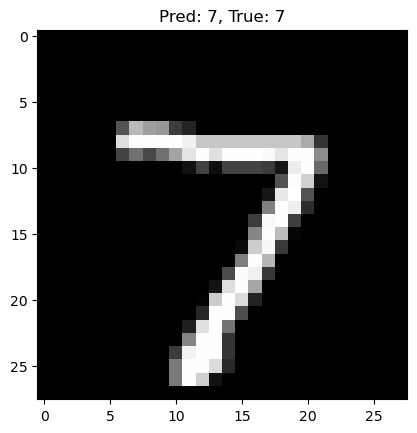

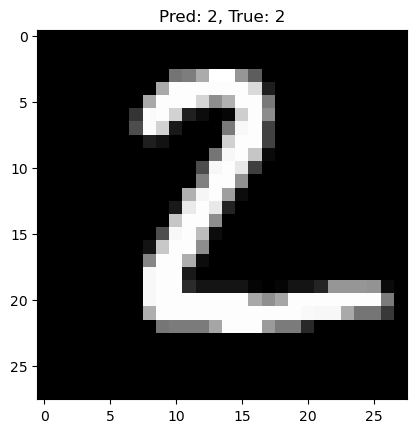

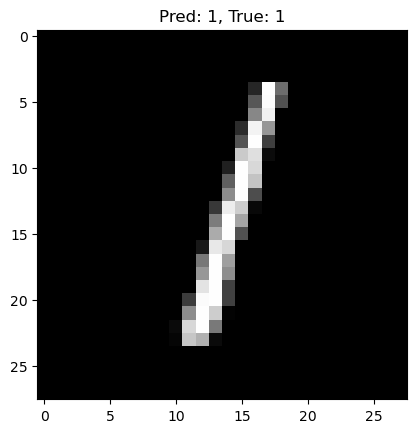

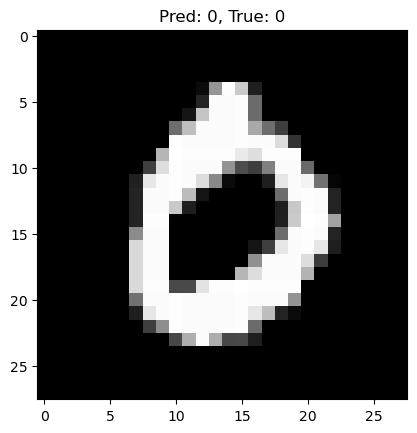

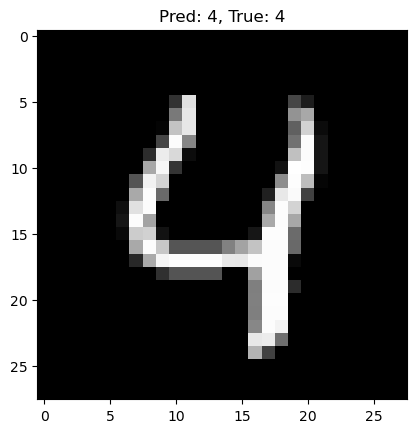

In [27]:
# ==== Examples of model performance ====

lightning_model.eval()
lightning_model.freeze()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lightning_model.to(device)

images, labels = next(iter(test_dataloader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = lightning_model(images)
    preds = outputs.argmax(dim=1)

for i in range(5):
    plt.imshow(images[i][0].cpu(), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}, True: {labels[i].item()}")
    plt.show()

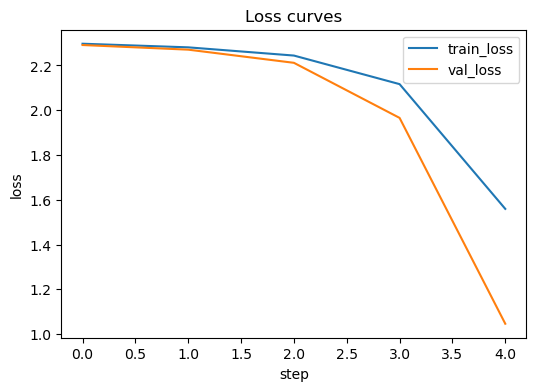

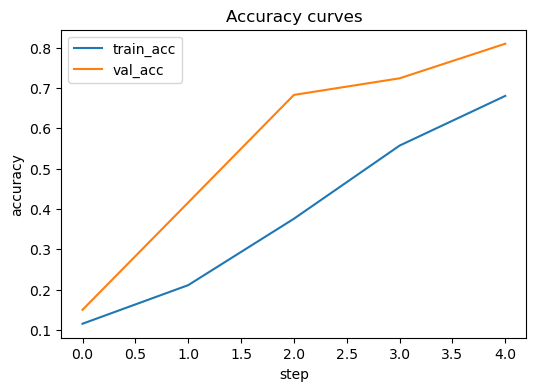

In [28]:
# ==== Loss and accuracy plots ====

metrics_path = glob.glob("logs/mnist/**/metrics.csv", recursive=True)[0]
metrics = pd.read_csv(metrics_path)

train_loss = metrics.dropna(subset=["train_loss"])["train_loss"].values
val_loss = metrics.dropna(subset=["val_loss"])["val_loss"].values

train_acc = metrics.dropna(subset=["train_acc"])["train_acc"].values
val_acc = metrics.dropna(subset=["val_acc"])["val_acc"].values

plt.figure(figsize=(6,4))
plt.plot(train_loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc, label="train_acc")
plt.plot(val_acc, label="val_acc")
plt.xlabel("step")
plt.ylabel("accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()